**Libraries**

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

**DATASET**

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Display sample image**

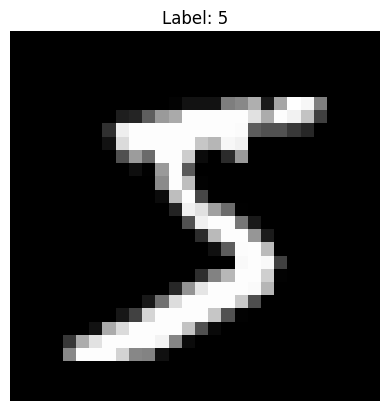

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


**Normalize Data**

In [5]:
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

**Flatten images for traditional ML models**

In [6]:
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat = X_test_norm.reshape(len(X_test_norm), -1)

**Evaluation**

In [7]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

**Logistic Regression**

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)
y_pred_lr = lr.predict(X_test_flat)
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


=== Logistic Regression ===
Accuracy: 0.9259
Precision: 0.9248943191389738
Recall: 0.9247910790540971
F1 Score: 0.9247747742435932


**Support Vector Machine**

In [9]:
svm = SVC()
svm.fit(X_train_flat, y_train)
y_pred_svm = svm.predict(X_test_flat)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")


=== Support Vector Machine ===
Accuracy: 0.9792
Precision: 0.9791973966593345
Recall: 0.9790919842945065
F1 Score: 0.9791298259748042


**Random Forest**

In [10]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)
evaluate_model(y_test, y_pred_rf, "Random Forest")


=== Random Forest ===
Accuracy: 0.969
Precision: 0.9688159450294119
Recall: 0.9687579711223275
F1 Score: 0.9687686514165698


**K-Nearest Neighbors**

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)
y_pred_knn = knn.predict(X_test_flat)
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")


=== K-Nearest Neighbors ===
Accuracy: 0.9688
Precision: 0.9692753386570571
Recall: 0.9684705010297703
F1 Score: 0.9687143421292884


**Convolutional Neural Network**

*Reshape input for CNN*

In [19]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

*One-hot encode labels*

In [20]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [21]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=128, validation_data=(X_test_cnn, y_test_cat), verbose=2)

Epoch 1/10
469/469 - 72s - 154ms/step - accuracy: 0.6184 - loss: 1.7878 - val_accuracy: 0.9366 - val_loss: 0.2140
Epoch 2/10
469/469 - 52s - 110ms/step - accuracy: 0.8922 - loss: 0.3806 - val_accuracy: 0.9725 - val_loss: 0.0919
Epoch 3/10
469/469 - 78s - 166ms/step - accuracy: 0.9337 - loss: 0.2336 - val_accuracy: 0.9783 - val_loss: 0.0746
Epoch 4/10
469/469 - 83s - 177ms/step - accuracy: 0.9506 - loss: 0.1778 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 5/10
469/469 - 81s - 172ms/step - accuracy: 0.9589 - loss: 0.1493 - val_accuracy: 0.9853 - val_loss: 0.0502
Epoch 6/10
469/469 - 81s - 173ms/step - accuracy: 0.9633 - loss: 0.1309 - val_accuracy: 0.9849 - val_loss: 0.0451
Epoch 7/10
469/469 - 83s - 177ms/step - accuracy: 0.9670 - loss: 0.1160 - val_accuracy: 0.9864 - val_loss: 0.0442
Epoch 8/10
469/469 - 81s - 172ms/step - accuracy: 0.9696 - loss: 0.1066 - val_accuracy: 0.9867 - val_loss: 0.0439
Epoch 9/10
469/469 - 47s - 101ms/step - accuracy: 0.9717 - loss: 0.1015 - val_accuracy: 

In [23]:
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
evaluate_model(y_test, y_pred_cnn, "CNN (Convolutional Neural Network)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

=== CNN (Convolutional Neural Network) ===
Accuracy: 0.9875
Precision: 0.9873607705791356
Recall: 0.9874628498892211
F1 Score: 0.987400531954514


**Comparison Table**

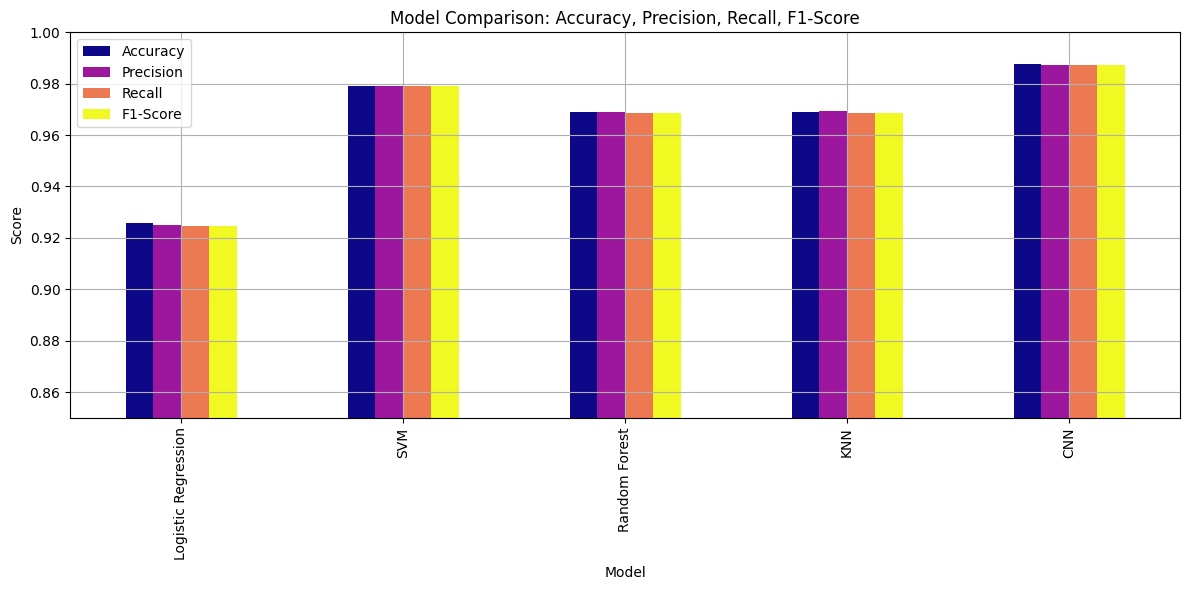

In [26]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1-Score': f1_score(y_true, y_pred, average='macro')
    }

metrics = [
    get_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    get_metrics(y_test, y_pred_svm, 'SVM'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
    get_metrics(y_test, y_pred_knn, 'KNN'),
    get_metrics(y_test, y_pred_cnn, 'CNN')
]

import pandas as pd
metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Model Comparison: Accuracy, Precision, Recall, F1-Score')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.grid(True)
plt.tight_layout()
plt.show()